# Solving the Traveling Salesman  Problem using Local Search

Points: 10

## The [Traveling Salesman Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem)

* __Goal:__ Find the shortest tour visiting each of $n$ cities exactly once and returning back to the starting city. Given are pairwise distances between cities, where $d_{i,j}$ is the distance from city $i$ to city $j$. 

* __State space:__ Each state represents a tour. The cities are numbered and a tour can be expressed as vector  $\pi$ with the order in which the cities are visited (a [permutation](https://en.wikipedia.org/wiki/Permutation)). That is, $\pi(1)$ is the index of the first city to visit, $\pi(2)$ the index of the second, and so on.

* __Objective function:__ Minimize the tour length. The optimization problem is to find the optimal tour $\pi^*$ through the $n$ cities and returning to the starting city:

  > minimize: $\mathrm{tourlength}(\pi) = d_{\pi(n),\pi(1)} + \sum_{i = 1}^{n-1} d_{\pi(i),\pi(i+1)}$
  > 
  > subject to: $\pi \ \text{is a valid permutation vector}$

* __Local moves:__ Exchange two cities in the order.

## Helper functions

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

np.set_printoptions(precision=2)
pd.set_option('display.precision', 2)

# make the results repeatable
np.random.seed(1234)

In [29]:
def random_tour(n):
    """Create a random tour"""
    
    tour = list(range(n))
    random.shuffle(tour)
    return(tour)

random_tour(10)

[0, 1, 4, 7, 5, 8, 3, 2, 9, 6]

In [30]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

def random_tsp(n):
    """
    Create a random (Euclidean) traveling salesman problem. Choose n points randomly in a 1 x 1 unit square and calulates a 
    pairwise Euclidean distance matrix.
    """
    
    pos = pd.DataFrame({
        "x" : np.random.uniform(size = n),
        "y" : np.random.uniform(size = n)
    })
    
    dist = squareform(pdist(pos))
    
    return({"pos": pos, "dist": dist})
    
tsp = random_tsp(10)

print(f"Positions:\n{tsp['pos']}")
print(f"Distance matrix:\n{pd.DataFrame(tsp['dist'])})")

Positions:
      x     y
0  0.19  0.36
1  0.62  0.50
2  0.44  0.68
3  0.79  0.71
4  0.78  0.37
5  0.27  0.56
6  0.28  0.50
7  0.80  0.01
8  0.96  0.77
9  0.88  0.88
Distance matrix:
      0     1     2     3     4     5     6     7     8     9
0  0.00  0.45  0.41  0.69  0.59  0.22  0.17  0.70  0.87  0.86
1  0.45  0.00  0.26  0.27  0.20  0.35  0.35  0.52  0.43  0.46
2  0.41  0.26  0.00  0.35  0.46  0.21  0.24  0.76  0.53  0.48
3  0.69  0.27  0.35  0.00  0.34  0.53  0.55  0.70  0.18  0.19
4  0.59  0.20  0.46  0.34  0.00  0.54  0.52  0.36  0.44  0.52
5  0.22  0.35  0.21  0.53  0.54  0.00  0.06  0.76  0.72  0.68
6  0.17  0.35  0.24  0.55  0.52  0.06  0.00  0.72  0.73  0.71
7  0.70  0.52  0.76  0.70  0.36  0.76  0.72  0.00  0.77  0.87
8  0.87  0.43  0.53  0.18  0.44  0.72  0.73  0.77  0.00  0.14
9  0.86  0.46  0.48  0.19  0.52  0.68  0.71  0.87  0.14  0.00)


In [31]:
def tour_length(tsp, tour):
    """Caclulate the length of a tour, i.e., the objective function."""
    
    # make sure tour is a Python list (not an array or a numpy.array)
    if not isinstance(tour, list): tour = tour.tolist()
    
    tl = 0
    dist = tsp["dist"]
    
    for i in range(len(tour)-1):
        tl += dist[tour[i], tour[i+1]]
    
    tl += dist[tour[-1], tour[0]]
    
    return(tl)
        
tour = random_tour(10)
tour_length(tsp, tour)

np.float64(4.6134127329057435)

Tour length: 4.61


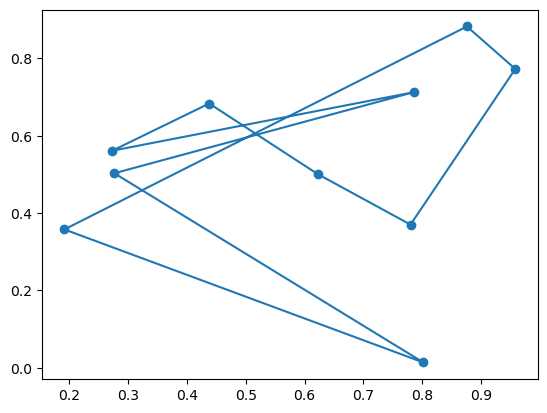

In [32]:
def show_tsp(tsp, tour = None):  
    """display the traveling salesman problem and a tour."""
    
    pos = tsp["pos"]
    
    plt.scatter(pos["x"], pos["y"])
    
    if tour is not None:
        # make sure tour is a Python list (not an array or a numpy.array)
        if not isinstance(tour, list): tour = tour.tolist()
        
        print(f"Tour length: {round(tour_length(tsp, tour), 2)}")
        
        pos_ = pos.reindex(tour)
        pos_ = pd.concat([pos_, pos_.head(1)], ignore_index=True)

        plt.plot(pos_["x"], pos_["y"])
    
    plt.show()
    
show_tsp(tsp, tour)

## Use R to find a solution

Load rpy2, make sure the R [TSP package](https://CRAN.R-project.org/package=TSP) is installed and prepare the distance matrix.

In [33]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [34]:
%%R
library(TSP)
library(microbenchmark)


In [35]:
%%R
if (!"TSP" %in% rownames(installed.packages())) {
    install.packages("TSP", repos="http://cran.us.r-project.org")
}

if (!"microbenchmark" %in% rownames(installed.packages())) {
    install.packages("microbenchmark", repos="http://cran.us.r-project.org")
}


Solve the TSP using [`solve_TSP`](https://www.rdocumentation.org/packages/TSP/versions/1.1-10/topics/solve_TSP) with the default heuristic. Note that 2-opt is steepest ascend hill climbing with exchanging two cities. `rep=100` means 100 random restarts.

In [ ]:

d = tsp["dist"]

Tour length: 4.61


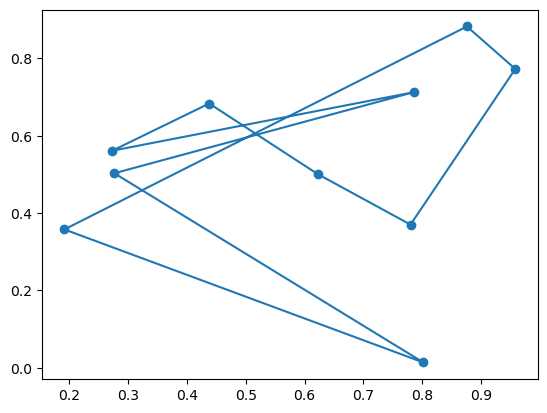

In [37]:
show_tsp(tsp, tour)

How long does it take to solve the problem 100 times?

In [38]:
%%R -i d

library("microbenchmark")

microbenchmark(tsp <- TSP(d))

Unit: microseconds
          expr   min    lq    mean median     uq    max neval
 tsp <- TSP(d) 178.3 184.9 215.328  191.6 211.75 1156.6   100


## Steepest-ascend Hill Climbing Search [3 Points] [Hiếu]

Calculate the objective function for all local moves (move each queen within its column) and always choose the best among all local moves.

In [39]:
# Code goes here
from helper import *

In [40]:
tsp = random_tsp(10)
solution, length, steps = hill_climbing(tsp)

In [41]:
print("=== Steepest-ascent Hill Climbing TSP ===")
print("Best tour found:", solution)
print("Tour length:", round(length, 2))
print("Steps taken:", steps)

=== Steepest-ascent Hill Climbing TSP ===
Best tour found: [1, 5, 4, 7, 9, 0, 2, 8, 3, 6]
Tour length: 2.67
Steps taken: 5


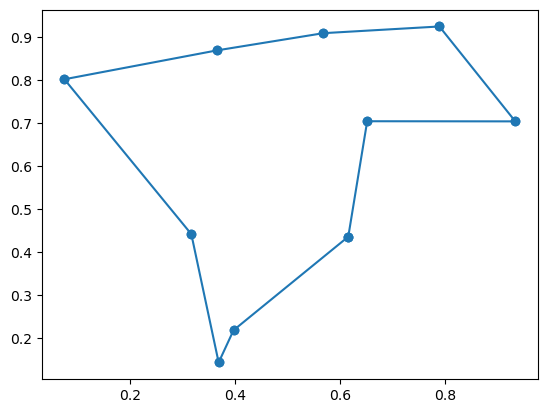

In [42]:
show_tsp(tsp, solution)

## Steepest-ascend Hill Climbing Search with Random Restarts [1 Point] [Hiếu]

Steepest-ascend with random restarts.

In [43]:
# Code goes here
tsp = random_tsp(10)
solution, best_len, total_steps, restarts = hill_climbing_random_restart(
    tsp, max_restarts=20)

In [44]:
print("=== Steepest-ascent Hill Climbing with Random Restarts TSP ===")
print("Best tour found:", solution)
print("Tour length:", round(best_len, 2))
print("Total steps:", total_steps)
print("Restarts:", restarts)

=== Steepest-ascent Hill Climbing with Random Restarts TSP ===
Best tour found: [6, 1, 2, 0, 3, 4, 9, 5, 7, 8]
Tour length: 3.04
Total steps: 133
Restarts: 12


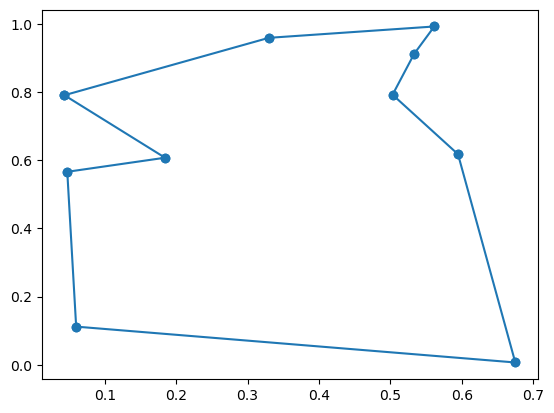

In [45]:
show_tsp(tsp, solution)

## Stochastic Hill Climbing [1 Points] [Hiếu]

Chooses randomly from among all uphill moves.

In [46]:
# Code goes here
tsp = random_tsp(10)
sol, sol_len, steps = stochastic_hillclimbing(tsp, max_steps=1000)

In [47]:
print("Best tour:", sol)
print("Length:", sol_len)
print("Steps:", steps)

Best tour: [3, 8, 9, 5, 0, 1, 7, 2, 6, 4]
Length: 3.027765288121562
Steps: 17


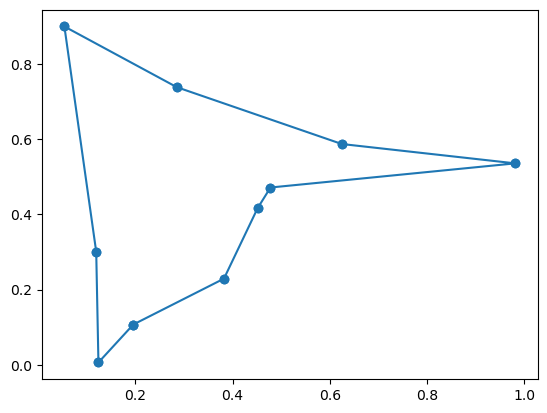

In [48]:
show_tsp(tsp, sol)

## First-choice Hill Climbing [1 Point]

First-choice hill climbing is a type of stochastic hill climbing that generates one random local neighbor at a time and accept it if it has a better objective function value than the current state.

In [ ]:
# Code goes here

import random

def first_choice_hill_climbing(objective_fn, initial_state, max_iterations=1000, neighbor_fn=None):
    current_state = initial_state
    current_value = objective_fn(current_state)
    
    for i in range(max_iterations):
        # generate a random neighbor
        neighbor = neighbor_fn(current_state)
        neighbor_value = objective_fn(neighbor)
        
        # accept if neighbor is better
        if neighbor_value > current_value:
            current_state = neighbor
            current_value = neighbor_value
            
    return current_state, current_value

def objective(x):
    return -(x-3)**2 + 9

# Neighbor function: add small random step
def neighbor(x):
    return x + random.uniform(-1, 1)

# Run algorithm
initial = random.uniform(-10, 10)
best_state, best_value = first_choice_hill_climbing(objective, initial, max_iterations=1000, neighbor_fn=neighbor)

print(f"Best state: {best_state:.4f}, Best value: {best_value:.4f}")


## Simulated Annealing [2 Points]

In [ ]:
# Code goes here

import math
import random

def simulated_annealing(objective_fn, initial_state, neighbor_fn, max_iterations=1000, initial_temp=100, cooling_rate=0.99):

    current_state = initial_state
    current_value = objective_fn(current_state)
    best_state = current_state
    best_value = current_value
    temp = initial_temp
    
    for i in range(max_iterations):
        neighbor = neighbor_fn(current_state)
        neighbor_value = objective_fn(neighbor)
        
        # Calculate change in objective
        delta = neighbor_value - current_value
        
        # Accept new state if better or with a probability
        if delta > 0 or random.random() < math.exp(delta / temp):
            current_state = neighbor
            current_value = neighbor_value
            
            # Update best if improved
            if current_value > best_value:
                best_state = current_state
                best_value = current_value
        
        # Cool down
        temp *= cooling_rate
    
    return best_state, best_value

# -------------------------
# Example usage
# -------------------------
# Objective function: maximize f(x) = -(x-3)^2 + 9 (peak at x=3)
def objective(x):
    return -(x-3)**2 + 9

# Neighbor function: small random step
def neighbor(x):
    return x + random.uniform(-1, 1)

# Initial state
initial = random.uniform(-10, 10)

# Run Simulated Annealing
best_state, best_value = simulated_annealing(objective, initial, neighbor, max_iterations=1000, initial_temp=50, cooling_rate=0.95)

print(f"Best state: {best_state:.4f}, Best value: {best_value:.4f}")


Best state: 2.9991, Best value: 9.0000


## Compare Performance [2 Points]

Use runtime, scalability (number of cities), and best objective function value to compare the algorithms on boards of different sizes.  

For timing you can use the `time` package.

In [51]:
import time

t0 = time.time()
print("Do something")
t1 = time.time()

print(f"This took: {(t1-t0) * 1e3} milliseconds")

Do something
This took: 0.0 milliseconds


In [52]:
# Code and results go here

import random
import time
import math

# -------------------------
# Utility functions
# -------------------------
def total_distance(path, dist_matrix):
    """Tính tổng quãng đường của một đường đi"""
    return sum(dist_matrix[path[i]][path[i+1]] for i in range(len(path)-1))

def random_neighbor(path):
    """Sinh neighbor bằng cách hoán đổi 2 vị trí ngẫu nhiên"""
    a, b = random.sample(range(len(path)), 2)
    neighbor = path[:]
    neighbor[a], neighbor[b] = neighbor[b], neighbor[a]
    return neighbor

# -------------------------
# First-choice Hill Climbing
# -------------------------
def fchc(dist_matrix, iterations=1000):
    n = len(dist_matrix)
    current = list(range(n))
    random.shuffle(current)
    best = current[:]
    best_val = -total_distance(best, dist_matrix)  # Maximize negative distance

    for _ in range(iterations):
        neighbor = random_neighbor(current)
        val = -total_distance(neighbor, dist_matrix)
        if val > best_val:
            best = neighbor
            best_val = val
            current = neighbor
    return best, -best_val

# -------------------------
# Simulated Annealing
# -------------------------
def simulated_annealing(dist_matrix, iterations=1000, initial_temp=100, cooling_rate=0.995):
    n = len(dist_matrix)
    current = list(range(n))
    random.shuffle(current)
    best = current[:]
    best_val = -total_distance(best, dist_matrix)
    temp = initial_temp

    for _ in range(iterations):
        neighbor = random_neighbor(current)
        val = -total_distance(neighbor, dist_matrix)
        delta = val - (-total_distance(current, dist_matrix))
        if delta > 0 or random.random() < math.exp(delta / temp):
            current = neighbor
            if val > best_val:
                best = neighbor
                best_val = val
        temp *= cooling_rate
    return best, -best_val

# -------------------------
# Test setup
# -------------------------
city_sizes = [5, 10, 15, 20]  # Number of cities
results = []

for n in city_sizes:
    # Random distance matrix
    dist_matrix = [[0 if i==j else random.randint(1, 100) for j in range(n)] for i in range(n)]

    # FCHC timing
    t0 = time.time()
    best_path_fchc, best_dist_fchc = fchc(dist_matrix)
    t1 = time.time()
    fchc_time = (t1-t0) * 1e3

    # SA timing
    t0 = time.time()
    best_path_sa, best_dist_sa = simulated_annealing(dist_matrix)
    t1 = time.time()
    sa_time = (t1-t0) * 1e3

    results.append((n, best_dist_fchc, fchc_time, best_dist_sa, sa_time))

# -------------------------
# Print results
# -------------------------
print(f"{'Cities':>6} | {'FCHC Dist':>10} | {'FCHC Time(ms)':>14} | {'SA Dist':>10} | {'SA Time(ms)':>12}")
print("-"*60)
for row in results:
    print(f"{row[0]:>6} | {row[1]:>10.2f} | {row[2]:>14.2f} | {row[3]:>10.2f} | {row[4]:>12.2f}")


Cities |  FCHC Dist |  FCHC Time(ms) |    SA Dist |  SA Time(ms)
------------------------------------------------------------
     5 |     134.00 |           5.80 |     119.00 |         9.34
    10 |     157.00 |           9.92 |     200.00 |         9.62
    15 |     315.00 |           5.01 |     236.00 |         8.40
    20 |     285.00 |           4.72 |     331.00 |         7.00


## Bonus: Genetic Algorithm [+1 Point]

In [53]:
# Code goes here

import random

# -------------------------
# Genetic Algorithm
# -------------------------
def create_population(n_cities, pop_size):
    """Khởi tạo population ngẫu nhiên"""
    population = []
    base_path = list(range(n_cities))
    for _ in range(pop_size):
        path = base_path[:]
        random.shuffle(path)
        population.append(path)
    return population

def crossover(parent1, parent2):
    """Ordered crossover (OX)"""
    size = len(parent1)
    a, b = sorted(random.sample(range(size), 2))
    child = [None]*size
    child[a:b] = parent1[a:b]

    ptr = 0
    for gene in parent2:
        if gene not in child:
            while child[ptr] is not None:
                ptr += 1
            child[ptr] = gene
    return child

def mutate(path, mutation_rate=0.1):
    """Swap mutation"""
    if random.random() < mutation_rate:
        a, b = random.sample(range(len(path)), 2)
        path[a], path[b] = path[b], path[a]
    return path

def genetic_algorithm(dist_matrix, pop_size=50, generations=200, mutation_rate=0.1):
    n_cities = len(dist_matrix)
    population = create_population(n_cities, pop_size)
    
    # Evaluate fitness (negative total distance because we maximize)
    fitness = lambda path: -sum(dist_matrix[path[i]][path[i+1]] for i in range(n_cities-1))

    best = population[0]
    best_val = fitness(best)

    for _ in range(generations):
        # Selection: tournament
        selected = []
        for _ in range(pop_size):
            a, b = random.sample(population, 2)
            selected.append(a if fitness(a) > fitness(b) else b)

        # Crossover to generate new population
        new_population = []
        for i in range(0, pop_size, 2):
            p1, p2 = selected[i], selected[i+1]
            child1 = crossover(p1, p2)
            child2 = crossover(p2, p1)
            new_population.extend([mutate(child1, mutation_rate), mutate(child2, mutation_rate)])

        population = new_population

        # Update best
        for path in population:
            val = fitness(path)
            if val > best_val:
                best_val = val
                best = path[:]

    return best, -best_val

# -------------------------
# Example run
# -------------------------
n = 10
dist_matrix = [[0 if i==j else random.randint(1, 100) for j in range(n)] for i in range(n)]

best_path_ga, best_dist_ga = genetic_algorithm(dist_matrix)
print("Best GA distance:", best_dist_ga)
print("Best GA path:", best_path_ga)


Best GA distance: 131
Best GA path: [6, 5, 4, 0, 3, 7, 9, 8, 1, 2]
